# AVIP 2026 — Task 1: IPL / Cricket Statistics Dashboard

Data source: https://github.com/Valkyrie31/EDA-IPL-2008-2024  
Extraction/documentation date: 2026-09-23

This notebook documents the IPL analysis required for AVIP Task 1: runs per match, top 10 run scorers, top 10 wicket takers, and team win percentages.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find project root automatically
BASE_DIR = Path.cwd()

if not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"

matches = pd.read_csv(DATA_DIR / "matches.csv")
deliveries = pd.read_csv(DATA_DIR / "deliveries.csv")

matches["season"] = matches["season"].astype(str)
matches["id"] = matches["id"].astype(str)
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
deliveries["match_id"] = deliveries["match_id"].astype(str)

print("Project:", BASE_DIR)
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Project: C:\Users\User\3D Objects\internship projects\AVIP_DS_Task1_IPL_Dashboard
Matches: (1095, 20)
Deliveries: (260920, 17)


In [2]:
# Basic data checks
print("Match date range:", matches["date"].min(), "to", matches["date"].max())
print("\nTop missing-value fields in matches:")
print(matches.isna().sum().sort_values(ascending=False).head(10))
print("\nTop missing-value fields in deliveries:")
print(deliveries.isna().sum().sort_values(ascending=False).head(10))


Match date range: 2008-04-18 00:00:00 to 2024-05-26 00:00:00

Top missing-value fields in matches:
method             1074
city                 51
result_margin        19
player_of_match       5
winner                5
target_runs           3
target_overs          3
id                    0
date                  0
season                0
dtype: int64

Top missing-value fields in deliveries:
fielder             251566
dismissal_kind      247970
player_dismissed    247970
extras_type         246795
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
non_striker              0
dtype: int64


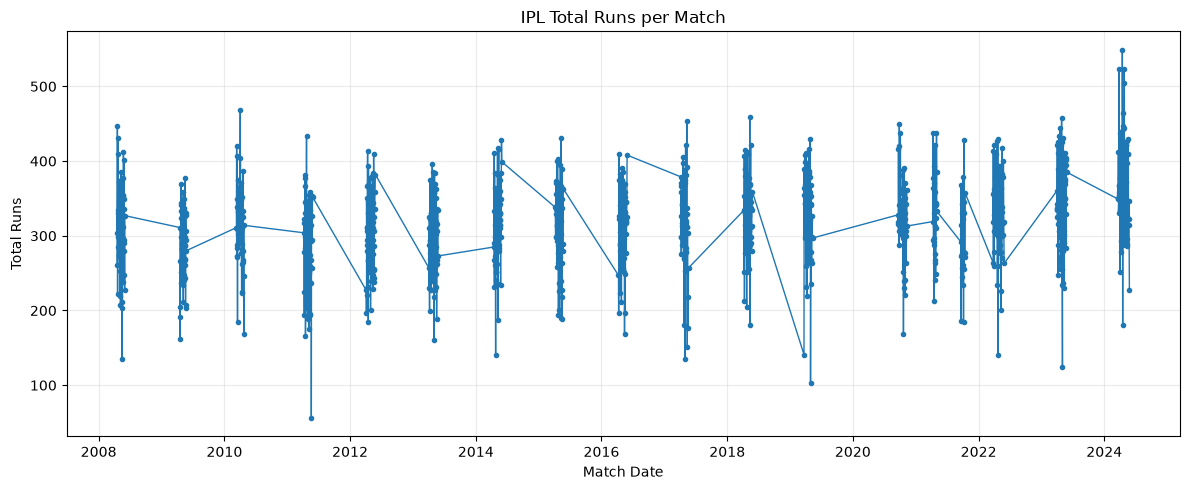

In [3]:
# Runs per match
match_runs = deliveries.groupby("match_id")["total_runs"].sum().reset_index()
runs = matches[["id","season","date","team1","team2"]].merge(
    match_runs, left_on="id", right_on="match_id", how="left"
)
runs["total_runs"] = runs["total_runs"].fillna(0)

plt.figure(figsize=(12,5))
tmp = runs.sort_values("date")
plt.plot(tmp["date"], tmp["total_runs"], marker=".", linewidth=1)
plt.title("IPL Total Runs per Match")
plt.xlabel("Match Date")
plt.ylabel("Total Runs")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


,batter,runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


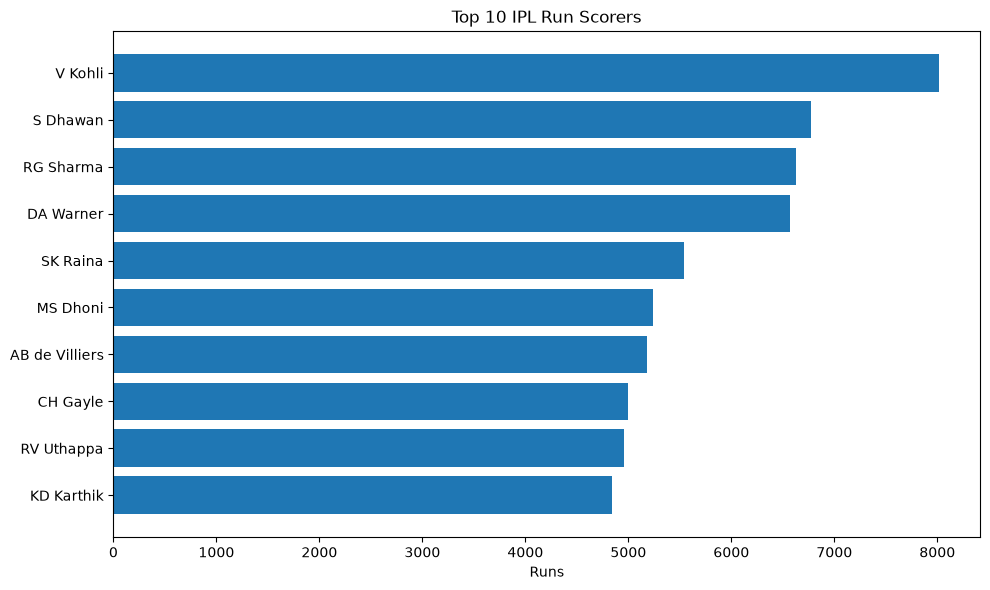

In [4]:
# Top 10 run scorers
run_scorers = (
    deliveries.groupby("batter")["batsman_runs"].sum()
    .reset_index().rename(columns={"batsman_runs":"runs"})
    .sort_values("runs", ascending=False)
)
top_runs = run_scorers.head(10)
display(top_runs)

plt.figure(figsize=(10,6))
p = top_runs.sort_values("runs")
plt.barh(p["batter"], p["runs"])
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Runs")
plt.tight_layout()
plt.show()


,bowler,wickets
445,YS Chahal,205
297,PP Chawla,192
102,DJ Bravo,183
61,B Kumar,181
304,R Ashwin,180
379,SP Narine,180
7,A Mishra,174
372,SL Malinga,170
168,JJ Bumrah,168
319,RA Jadeja,160


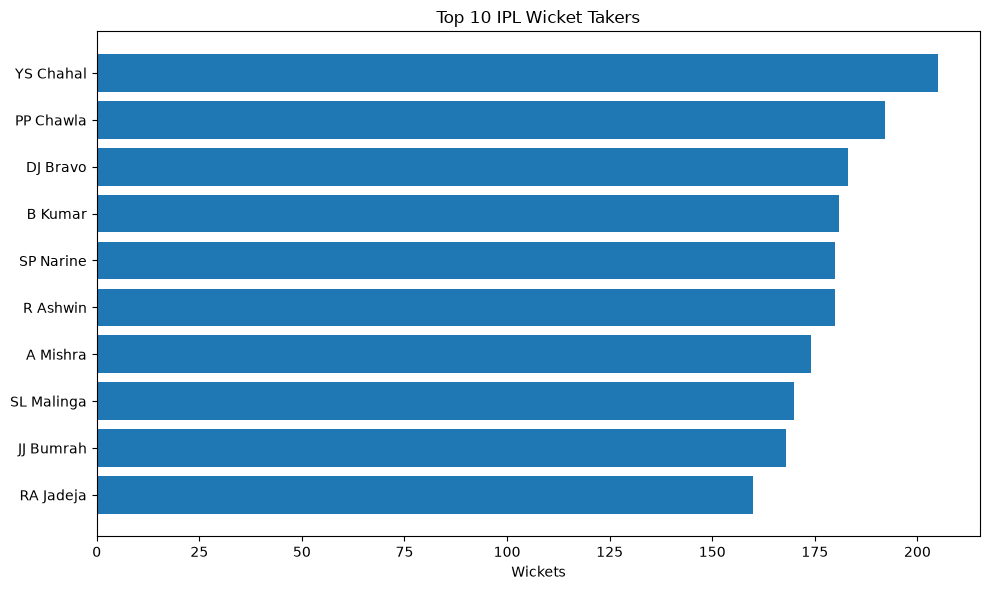

In [5]:
# Top 10 wicket takers
credited = ["bowled","caught","caught and bowled","lbw","stumped","hit wicket"]
wickets = deliveries[deliveries["player_dismissed"].notna()].copy()
wickets = wickets[wickets["dismissal_kind"].fillna("").str.lower().isin(credited)]

wicket_takers = wickets.groupby("bowler").size().reset_index(name="wickets").sort_values("wickets", ascending=False)
top_wickets = wicket_takers.head(10)
display(top_wickets)

plt.figure(figsize=(10,6))
p = top_wickets.sort_values("wickets")
plt.barh(p["bowler"], p["wickets"])
plt.title("Top 10 IPL Wicket Takers")
plt.xlabel("Wickets")
plt.tight_layout()
plt.show()


,team,matches,wins,win_percentage
14,Rising Pune Supergiant,16,10,62.500000
5,Gujarat Titans,45,28,62.222222
0,Chennai Super Kings,238,138,57.983193
10,Mumbai Indians,261,144,55.172414
9,Lucknow Super Giants,44,24,54.545455
2,Delhi Capitals,91,48,52.747253
8,Kolkata Knight Riders,251,131,52.191235
13,Rajasthan Royals,221,112,50.678733
18,Sunrisers Hyderabad,182,88,48.351648
16,Royal Challengers Bangalore,240,116,48.333333


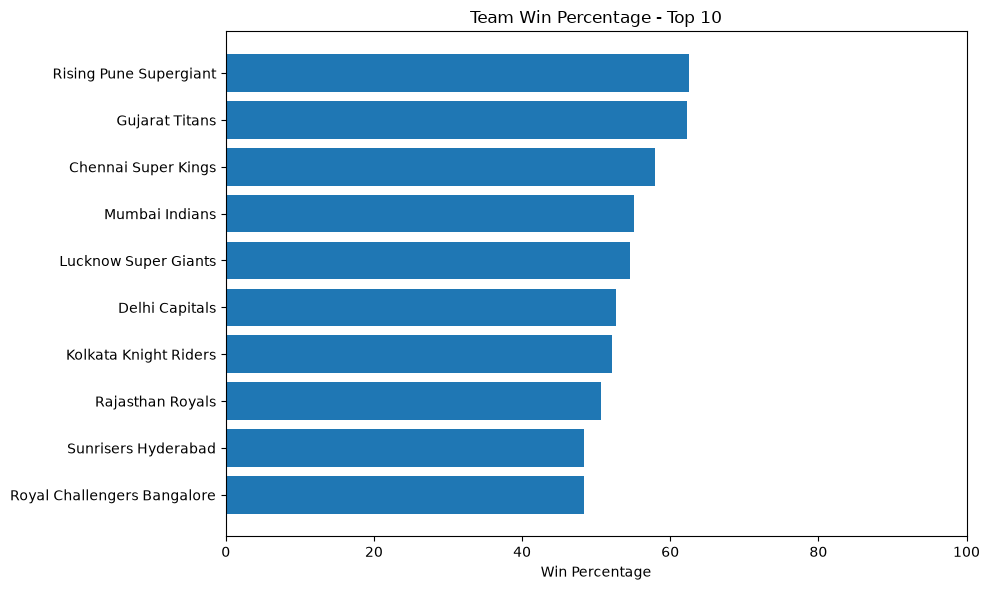

In [6]:
# Team win percentages
rows = []
for _, row in matches.iterrows():
    winner = "" if pd.isna(row["winner"]) else str(row["winner"]).strip()
    for col in ["team1","team2"]:
        team = "" if pd.isna(row[col]) else str(row[col]).strip()
        if team:
            rows.append({"season":str(row["season"]), "team":team, "won":int(team == winner)})

team_results = pd.DataFrame(rows)
team_stats = team_results.groupby("team").agg(matches=("won","size"), wins=("won","sum")).reset_index()
team_stats["win_percentage"] = team_stats["wins"] / team_stats["matches"] * 100
top_win_pct = team_stats.sort_values("win_percentage", ascending=False).head(10)
display(top_win_pct)

plt.figure(figsize=(10,6))
p = top_win_pct.sort_values("win_percentage")
plt.barh(p["team"], p["win_percentage"])
plt.title("Team Win Percentage - Top 10")
plt.xlabel("Win Percentage")
plt.xlim(0,100)
plt.tight_layout()
plt.show()


In [7]:
# Generate the final interactive dashboard
import runpy
runpy.run_path(str(BASE_DIR / "src" / "build_dashboard.py"))
print("Dashboard:", OUTPUT_DIR / "ipl_dashboard.html")


AVIP 2026 - IPL Cricket Statistics Dashboard

[1/6] Loading datasets...


Loaded 1,095 matches.
Loaded 260,920 deliveries.

[2/6] Computing metrics...


Metrics calculated successfully.

[3/6] Creating static charts...


Static charts created.

[4/6] Preparing interactive dashboard...



[5/6] Creating insights summary...

[6/6] Dashboard complete.

SUCCESS! Updated Task 1 dashboard is ready.

Open:
C:\Users\User\3D Objects\internship projects\AVIP_DS_Task1_IPL_Dashboard\outputs\ipl_dashboard.html
Dashboard: C:\Users\User\3D Objects\internship projects\AVIP_DS_Task1_IPL_Dashboard\outputs\ipl_dashboard.html


## Conclusion

The notebook analyzes IPL scoring, leading run scorers, leading wicket takers, and team win percentages. The final interactive dashboard provides season and team filters and is saved in the `outputs/` directory.